# Classification baseline models
* Multiple classification models are compared on a slice-based stenosis classification task. 
* Is classification itself enough?
* Which classification architecture performs best on slice-based lumbar MRI classification?

### Dataset
Lumbar MRI Classification Dataset (Mendeley / Kaggle):
* https://www.kaggle.com/datasets/abdullahkhan70/lumbar-spinal-mri-dataset
* https://data.mendeley.com/datasets/k57fr854j2/2
    
### Classification Benchmark Models 
1. VGG
2. ResNet
3. DenseNet
4. EfficientNet
5. Vision Transformer (ViT)
6. Swin Transformer

Models for pytorch implementation: https://docs.pytorch.org/vision/main/models.html

Tady typek to umi trochu lip:
https://www.kaggle.com/code/hridoyahmed221155935/lumber-spine

## Dataset preprocessing

In [1]:
# IMPORTS 
import os
import re
import copy
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

In [2]:
# SET SEED FOR REPRODUCIBILITY
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [3]:
os.chdir("/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/BC-data")
print(os.getcwd())

/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/BC-data


In [4]:
# SPLIT TO PREVENT DATA LEAKAGE
TRAIN_DIR = "./data-classification/train"

def extract_num(fname):
    m = re.search(r"image_(\d+)\.jpg$", fname)
    return int(m.group(1)) if m else None

records = []

for cls in os.listdir(TRAIN_DIR):
    cls_path = os.path.join(TRAIN_DIR, cls)
    if not os.path.isdir(cls_path):
        continue
    
    for fname in os.listdir(cls_path):
        if not fname.endswith(".jpg"):
            continue
        
        num_id = extract_num(fname)
        if num_id is None:
            continue
        
        records.append({
            "path": os.path.join(cls_path, fname),
            "label": cls,
            "num_id": num_id
        })

df = pd.DataFrame(records)

# label encoding
CLASS_NAMES = sorted(df["label"].unique())
label2id = {l: i for i, l in enumerate(CLASS_NAMES)}
df["label_id"] = df["label"].map(label2id)

print(df.shape)
print(df["label"].value_counts())

(10948, 4)
label
Thecal Sac        4733
No Stenosis       3152
Herniated Disc    3063
Name: count, dtype: int64


In [5]:
def extract_num(fname):
    m = re.search(r"image_(\d+)\.jpg$", fname)
    return int(m.group(1)) if m else None

train_records = []

for cls in os.listdir(TRAIN_DIR):
    cls_path = os.path.join(TRAIN_DIR, cls)
    if not os.path.isdir(cls_path):
        continue

    for fname in os.listdir(cls_path):
        if not fname.lower().endswith(".jpg"):
            continue

        num_id = extract_num(fname)
        if num_id is None:
            continue

        train_records.append({
            "path": os.path.join(cls_path, fname),
            "label": cls,
            "filename": fname,
            "num_id": num_id
        })

train_df = pd.DataFrame(train_records)

CLASS_NAMES = sorted(train_df["label"].unique())
label2id = {label: i for i, label in enumerate(CLASS_NAMES)}
id2label = {i: label for label, i in label2id.items()}

train_df["label_id"] = train_df["label"].map(label2id)

print("Classes:", CLASS_NAMES)
print(train_df["label"].value_counts())
train_df.head()

Classes: ['Herniated Disc', 'No Stenosis', 'Thecal Sac']
label
Thecal Sac        4733
No Stenosis       3152
Herniated Disc    3063
Name: count, dtype: int64


,path,label,filename,num_id,label_id
0,./data-classification/train/No Stenosis/image_...,No Stenosis,image_7535.jpg,7535,1
1,./data-classification/train/No Stenosis/image_...,No Stenosis,image_1916.jpg,1916,1
2,./data-classification/train/No Stenosis/image_...,No Stenosis,image_5449.jpg,5449,1
3,./data-classification/train/No Stenosis/image_...,No Stenosis,image_2807.jpg,2807,1
4,./data-classification/train/No Stenosis/image_...,No Stenosis,image_7530.jpg,7530,1


In [6]:
def blocked_train_val_split_per_class(df, train_ratio=0.8, gap=10):
    train_parts, val_parts = [], []

    for cls, sub in df.groupby("label"):
        sub = sub.sort_values("num_id").reset_index(drop=True)
        n = len(sub)

        split_idx = int(train_ratio * n)

        train_sub = sub.iloc[:max(0, split_idx - gap)]
        val_sub = sub.iloc[min(n, split_idx + gap):]

        train_parts.append(train_sub)
        val_parts.append(val_sub)

    train_df = pd.concat(train_parts).reset_index(drop=True)
    val_df = pd.concat(val_parts).reset_index(drop=True)

    return train_df, val_df

train_df, val_df = blocked_train_val_split_per_class(
    train_df,
    train_ratio=0.8,
    gap=10
)

print("Train counts:\n", train_df["label"].value_counts(), "\n")
print("Val counts:\n", val_df["label"].value_counts(), "\n")

Train counts:
 label
Thecal Sac        3776
No Stenosis       2511
Herniated Disc    2440
Name: count, dtype: int64 

Val counts:
 label
Thecal Sac        937
No Stenosis       621
Herniated Disc    603
Name: count, dtype: int64 



In [7]:
# TRANSFORMS
mean = [0.1669754, 0.1669754, 0.1669754]
std  = [0.2372296, 0.2372296, 0.2372296]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomRotation(5),
    transforms.RandomAffine(degrees=0, translate=(0.02, 0.02)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [8]:
# CUSTOM DATASET DEFINITION
class LumbarClassificationDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        
        if self.transform is not None:
            image = self.transform(image)
        
        label = int(row["label_id"])
        return image, label

In [9]:
# BUILD DATASETS 
train_dataset = LumbarClassificationDataset(train_df, transform=train_transform)
val_dataset   = LumbarClassificationDataset(val_df, transform=val_transform)

test_dataset = ImageFolder(
    root="./data-classification/test",
    transform=val_transform
)


In [10]:
#BUILD LOADERS
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## Training setup

In [11]:
#DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [12]:
#BUILD MODEL
num_classes = len(CLASS_NAMES)

model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)
model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=3, bias=True)


In [13]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")
    
    return epoch_loss, epoch_acc, epoch_f1

In [15]:
@torch.no_grad()
def evaluate_one_epoch(model, loader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        running_loss += loss.item() * images.size(0)
        
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")
    
    return epoch_loss, epoch_acc, epoch_f1, np.array(all_labels), np.array(all_preds)

In [16]:
# FULL TRAINING LOOP 
def fit_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs=10):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_f1 = -np.inf
    
    history = {
        "train_loss": [],
        "train_acc": [],
        "train_f1": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": []
    }
    
    start_time = time.time()
    
    for epoch in range(epochs):
        train_loss, train_acc, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        val_loss, val_acc, val_f1, _, _ = evaluate_one_epoch(
            model, val_loader, criterion, device
        )
        
        scheduler.step(val_f1)
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)
        
        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}"
        )
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(best_model_wts, "best_resnet34_blocked_split.pth")
            print(f"  -> Best model saved with Val F1: {best_val_f1:.4f}")
    
    elapsed = time.time() - start_time
    print(f"\nTraining complete in {elapsed/60:.2f} minutes")
    print(f"Best Val F1: {best_val_f1:.4f}")
    
    model.load_state_dict(best_model_wts)
    return model, history

In [17]:
model, history = fit_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    epochs=10
)

Epoch [1/10] | Train Loss: 0.8749, Train Acc: 0.5906, Train F1: 0.5758 | Val Loss: 1.6373, Val Acc: 0.3892, Val F1: 0.3334
  -> Best model saved with Val F1: 0.3334
Epoch [2/10] | Train Loss: 0.4487, Train Acc: 0.8172, Train F1: 0.8124 | Val Loss: 1.9869, Val Acc: 0.4188, Val F1: 0.4116
  -> Best model saved with Val F1: 0.4116
Epoch [3/10] | Train Loss: 0.2505, Train Acc: 0.9059, Train F1: 0.9040 | Val Loss: 2.4213, Val Acc: 0.4118, Val F1: 0.3835
Epoch [4/10] | Train Loss: 0.1561, Train Acc: 0.9428, Train F1: 0.9420 | Val Loss: 2.3404, Val Acc: 0.3753, Val F1: 0.3615
Epoch [5/10] | Train Loss: 0.0955, Train Acc: 0.9678, Train F1: 0.9674 | Val Loss: 3.2279, Val Acc: 0.3767, Val F1: 0.3669
Epoch [6/10] | Train Loss: 0.0428, Train Acc: 0.9857, Train F1: 0.9855 | Val Loss: 2.6721, Val Acc: 0.4160, Val F1: 0.3986
Epoch [7/10] | Train Loss: 0.0223, Train Acc: 0.9939, Train F1: 0.9939 | Val Loss: 2.7793, Val Acc: 0.4216, Val F1: 0.3976
Epoch [8/10] | Train Loss: 0.0266, Train Acc: 0.9908, T

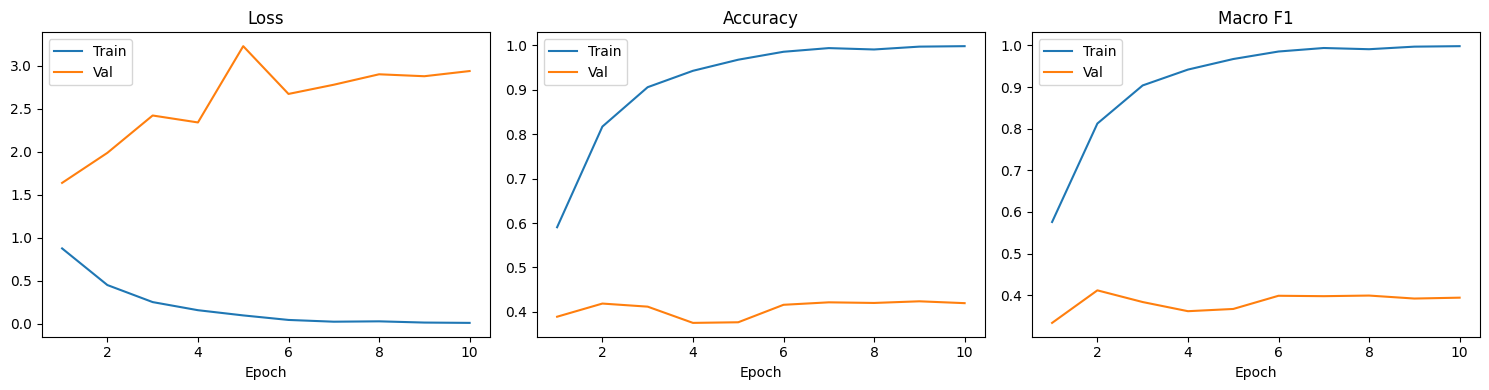

In [18]:
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    
    plt.figure(figsize=(15, 4))
    
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], label="Train")
    plt.plot(epochs, history["val_loss"], label="Val")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.legend()
    
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_acc"], label="Train")
    plt.plot(epochs, history["val_acc"], label="Val")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.legend()
    
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["train_f1"], label="Train")
    plt.plot(epochs, history["val_f1"], label="Val")
    plt.title("Macro F1")
    plt.xlabel("Epoch")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_history(history)

## Evaluate model

In [19]:
# TEST DATASET 
test_loss, test_acc, test_f1, y_true_test, y_pred_test = evaluate_one_epoch(
    model, test_loader, criterion, device
)

print("Blocked split test")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}")
print(f"Macro F1: {test_f1:.4f}")

Blocked split test
Loss: 1.7660
Accuracy: 0.4675
Macro F1: 0.3391


In [20]:
def show_confusion_and_report(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    
    plt.tight_layout()
    plt.show()
    
    print(classification_report(y_true, y_pred, target_names=class_names))

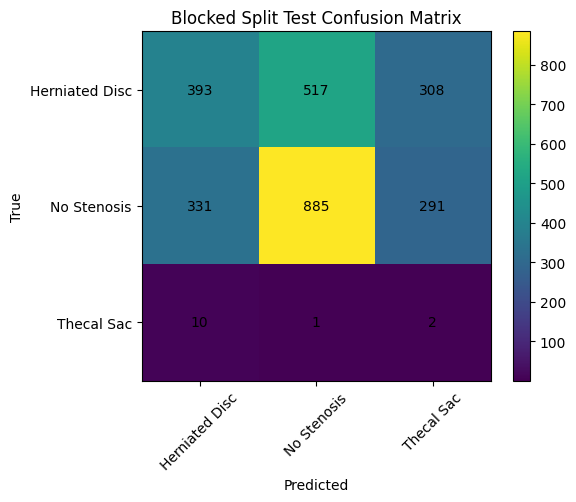

                precision    recall  f1-score   support

Herniated Disc       0.54      0.32      0.40      1218
   No Stenosis       0.63      0.59      0.61      1507
    Thecal Sac       0.00      0.15      0.01        13

      accuracy                           0.47      2738
     macro avg       0.39      0.35      0.34      2738
  weighted avg       0.59      0.47      0.51      2738



In [21]:
show_confusion_and_report(
    y_true_test,
    y_pred_test,
    CLASS_NAMES,
    title="Blocked Split Test Confusion Matrix"
)